# Classification and Generation with KDM

This notebook illustrates how to use [Kernel Density Matrices](https://github.com/fagonzalezo/kdm) for classification and generation.

In [ ]:
# Uncomment to install the required packages
# !pip install git+https://github.com/fagonzalezo/kdm.git

In [1]:
import numpy as np
from scipy.stats import norm
from scipy.stats import gaussian_kde

import os
os.environ["KERAS_BACKEND"] = "torch"

import keras
from keras import optimizers
from keras import losses
from keras import metrics
from keras.callbacks import ModelCheckpoint


from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

from kdm.models import KDMClassModel
import kdm

import matplotlib.pyplot as plt

In [2]:
# Create a 2 moons dataset
X, y = make_moons(n_samples=1000, noise=0.2, random_state=0)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)


/var/folders/p_/nhqsddwd6w3923l9m2_nxxzm0000gp/T/ipykernel_7950/1052752255.py:7: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(this_X[:, 0], this_X[:, 1],  c=color,


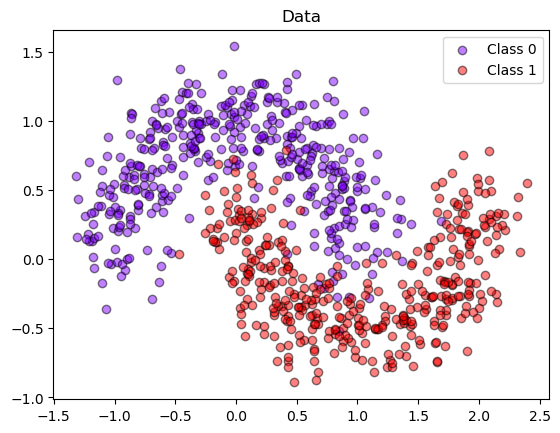

In [3]:
# Function to visualize a 2D dataset
def plot_data(X, y):
    y_unique = np.unique(y)
    colors = plt.cm.rainbow(np.linspace(0.0, 1.0, y_unique.size))
    for this_y, color in zip(y_unique, colors):
        this_X = X[y == this_y]
        plt.scatter(this_X[:, 0], this_X[:, 1],  c=color,
                    alpha=0.5, edgecolor='k',
                    label="Class %s" % this_y)
    plt.legend(loc="best")
    plt.title("Data")

# Function to visualize the decission surface of a classifier
def plot_decision_region(X, pred_fun):
    min_x = np.min(X[:, 0])
    max_x = np.max(X[:, 0])
    min_y = np.min(X[:, 1])
    max_y = np.max(X[:, 1])
    min_x = min_x - (max_x - min_x) * 0.05
    max_x = max_x + (max_x - min_x) * 0.05
    min_y = min_y - (max_y - min_y) * 0.05
    max_y = max_y + (max_y - min_y) * 0.05
    x_vals = np.linspace(min_x, max_x, 50)
    y_vals = np.linspace(min_y, max_y, 50)
    XX, YY = np.meshgrid(x_vals, y_vals)
    grid_r, grid_c = XX.shape
    vals = [[XX[i, j], YY[i, j]] for i in range(grid_r) for j in range(grid_c)]
    preds = pred_fun(np.array(vals))
    ZZ = np.reshape(preds, (grid_r, grid_c))
    print(np.min(preds), np.min(ZZ))
    plt.contourf(XX, YY, ZZ, 100, cmap = plt.cm.coolwarm, vmin= 0, vmax=1)
    plt.colorbar()
    CS = plt.contour(XX, YY, ZZ, 100, levels = [0.1*i for i in range(1,10)])
    plt.clabel(CS, inline=1, fontsize=10)
    plt.xlabel("x")
    plt.ylabel("y")

def gen_pred_fun(clf):
    def pred_fun(X):
        return clf.predict(X)[:, 1]
    return pred_fun

plot_data(X_train, y_train)

## 1 Generative classification two moons

The following example illustrates the use of the inference process using a generative classification model.

In general, the KDM classification model minimizes the following lost function:

$$
L(x^{(i)}, y^{(i)}) = - \sum_{k=1}^K 1(y^{(i)} == k) \log  P(y=k | x^{(i)}) - \alpha \log P(x^{(i)})
$$

Both $P(y=k | x^{(i)})$ and $P(x^{(i)})$ are predictions of the KDM model. $\alpha$ controls the importance of the generative component of the loss.

We use the KDMClassModel to train a shallow model that directly apply a KDM inference layer to the raw data. This class assumes a continuos distribution for the input data (i.e. it uses an RBF kernel) and a discrete distribution for the output data. The `generative` parameter corresponds to the $\alpha$ parameter controlling the importance of the generative term of the loss function.

In [13]:
encoded_size = 2
dim_y = 2
encoder = keras.Sequential([keras.layers.Identity()])
n_comp = 14

kdm_model = KDMClassModel(encoded_size=encoded_size,
                            dim_y=dim_y,
                            encoder=encoder,
                            n_comp=n_comp,
                            sigma=0.05,
                            generative=1.)

# train the classifier
kdm_model.compile(optimizer=optimizers.Adam(learning_rate=5e-3),
                    loss=keras.losses.sparse_categorical_crossentropy,
                    metrics=[metrics.sparse_categorical_accuracy])
kdm_model.predict(X_train[:10])
idx = np.random.randint(X_train.shape[0], size=n_comp)
kdm_model.init_components(X_train[idx],
                          np.eye(2)[y_train[idx]],
                          init_sigma=True)

print(f'Sigma: {kdm_model.kernel.sigma.numpy()}')
kdm_model.fit(X_train, y_train, epochs=25, batch_size=32, verbose=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Sigma: 0.38436660170555115
Epoch 1/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.4605 - sparse_categorical_accuracy: 0.9332
Epoch 2/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2944 - sparse_categorical_accuracy: 0.9363
Epoch 3/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2275 - sparse_categorical_accuracy: 0.9417
Epoch 4/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.0683 - sparse_categorical_accuracy: 0.9530
Epoch 5/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5.9588 - sparse_categorical_accuracy: 0.9586
Epoch 6/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5.9117 - sparse_categorical_accuracy: 0.9670
Epoch 7/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5.8518 - sparse_categorical_accuracy: 0.9600
Epoch 8/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5.8620 - sparse_categorical_accuracy: 0.9674
Epoch 9/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5.7709 - sparse_

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 953us/step
8.523541e-10 8.523541e-10
Test loss: 5.783970832824707
Test accuracy: 0.9700000286102295
Sigma: 0.28381577134132385


/var/folders/p_/nhqsddwd6w3923l9m2_nxxzm0000gp/T/ipykernel_7950/1052752255.py:7: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(this_X[:, 0], this_X[:, 1],  c=color,


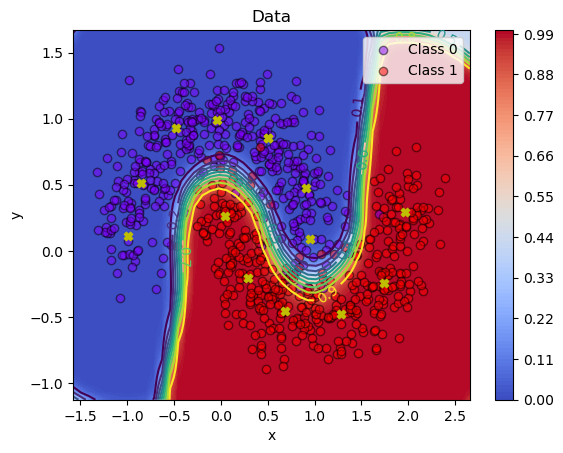

In [15]:
# Plot the decision region
plot_decision_region(X, gen_pred_fun(kdm_model))
plot_data(X_train, y_train)
# plot the prototypes
c_x = keras.ops.convert_to_numpy(kdm_model.kdm.c_x)
plt.scatter(c_x[:, 0], c_x[:, 1], c='y', marker='X')
# Evaluate the classifier
score = kdm_model.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])
print(f'Sigma: {kdm_model.kernel.sigma.numpy()}')

The above visualization shows the decision boundary of the classifier model along with the prototypes of the model. The prototypes are shown as yellow crosses. Because of the likelihood maximization, prototypes are distributed evenly in the input space to maximize the density of the input samples. The classification performance in on par with the discriminative model.

## MNIST example

An example using the mnist dataset. In addition to perform classification we will show how to perform generation.

In [16]:
# Create a dataset from mnist using tf
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()
X_train = X_train.astype('float32') / 255.
X_test = X_test.astype('float32') / 255.


# reshape the data to include a channel dimension
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1)
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1)

# Partition the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.8, random_state=42)

def display_imgs(x, y=None):
    if not isinstance(x, (np.ndarray, np.generic)):
      x = np.array(x)
    plt.ioff()
    n = x.shape[0]
    fig, axs = plt.subplots(1, n, figsize=(n, 1))
    if y is not None:
      fig.suptitle(np.argmax(y, axis=1))
    for i in range(n):
      axs.flat[i].imshow(x[i].squeeze(), interpolation='none', cmap='gray')
      axs.flat[i].axis('off')
    plt.show()
    plt.close()
    plt.ion()


We define a deep encoder that will be used to map input images to a low-dimensional latent space.

In [17]:
kl = keras.layers

def create_encoder(input_shape, base_depth, encoded_size):
    encoder = keras.Sequential([
    kl.InputLayer(shape=input_shape),
    kl.Lambda(lambda x: x - 0.5),
    kl.Conv2D(base_depth, 5, strides=1,
                    padding='same', activation=keras.ops.leaky_relu),
    kl.Conv2D(base_depth, 5, strides=2,
                    padding='same', activation=keras.ops.leaky_relu),
    kl.Conv2D(2 * base_depth, 5, strides=1,
                    padding='same', activation=keras.ops.leaky_relu),
    kl.Conv2D(2 * base_depth, 5, strides=2,
                    padding='same', activation=keras.ops.leaky_relu),
    kl.Conv2D(4 * encoded_size, 7, strides=1,
                    padding='valid', activation=keras.ops.leaky_relu),
    kl.Dense(encoded_size, activation=None),
        #kl.LayerNormalization(),
    kl.Flatten(),
    ])
    return encoder

The classifier model (KDMClassModel) receives as input the encoder, and applies it before applying the KDM inference layer. First we train a discriminative classification model. 

In [ ]:
# Define the encoder
input_shape = (28, 28, 1)
base_depth = 32
encoded_size = 2
encoder = create_encoder(input_shape, base_depth, encoded_size)

# warm up the encoder
encoder_wmp = keras.Sequential([encoder, 
                                  keras.layers.Dense(10, activation='softmax')])
encoder_wmp.predict(X_train[:10])
encoder_wmp.compile(optimizer=optimizers.Adam(learning_rate=1e-3),
                loss=losses.sparse_categorical_crossentropy,
                metrics=[metrics.sparse_categorical_accuracy])
encoder_wmp.fit(X_train, y_train, epochs=1, batch_size=64, verbose=1)
# Create a classifier model
dim_y = 10
n_comp = 64

kdm_mnist = KDMClassModel(encoded_size=encoded_size,
                            dim_y=dim_y,
                            encoder=encoder,
                            n_comp=n_comp,
                            sigma=0.1,
                            generative=0. # this value indicates a discriminative model
                            )

# initialize the prototypes using random samples from the training set
idx = np.random.randint(X_train.shape[0], size=n_comp)
kdm_mnist.init_components(X_train[idx], keras.ops.one_hot(y_train[idx], 10), 
                          init_sigma=True, sigma_mult=1.0)

print(f'Sigma: {kdm_mnist.kernel.sigma.numpy()}')

# Compile the model
kdm_mnist.compile(optimizer=optimizers.Adam(learning_rate=1e-3),
                    loss=losses.sparse_categorical_crossentropy,
                    metrics=[metrics.sparse_categorical_accuracy])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
188/188 ━━━━━━━━━━━━━━━━━━━━ 76s 405ms/step - loss: 1.6629 - sparse_categorical_accuracy: 0.3752
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Sigma: 3.9985079765319824


In [19]:
# Train the kdm discriminative model
kdm_mnist.fit(X_train, y_train, validation_data=(X_val[:1000], y_val[:1000]), epochs=10, batch_size=128, verbose=1)
print(f'Final Sigma: {kdm_mnist.kernel.sigma.numpy()}')


Epoch 1/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 74s 787ms/step - loss: 0.9414 - sparse_categorical_accuracy: 0.7807 - val_loss: 0.5337 - val_sparse_categorical_accuracy: 0.8980
Epoch 2/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 79s 843ms/step - loss: 0.4383 - sparse_categorical_accuracy: 0.9016 - val_loss: 0.3913 - val_sparse_categorical_accuracy: 0.9170
Epoch 3/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 74s 780ms/step - loss: 0.3615 - sparse_categorical_accuracy: 0.9203 - val_loss: 0.4705 - val_sparse_categorical_accuracy: 0.8890
Epoch 4/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 66s 706ms/step - loss: 0.3184 - sparse_categorical_accuracy: 0.9362 - val_loss: 0.3354 - val_sparse_categorical_accuracy: 0.9310
Epoch 5/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 63s 668ms/step - loss: 0.3078 - sparse_categorical_accuracy: 0.9343 - val_loss: 0.3353 - val_sparse_categorical_accuracy: 0.9340
Epoch 6/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 63s 670ms/step - loss: 0.2672 - sparse_categorical_accuracy: 0.9473 - val_loss: 0.3296 - val_sparse_categorical_accuracy: 0.942

157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step


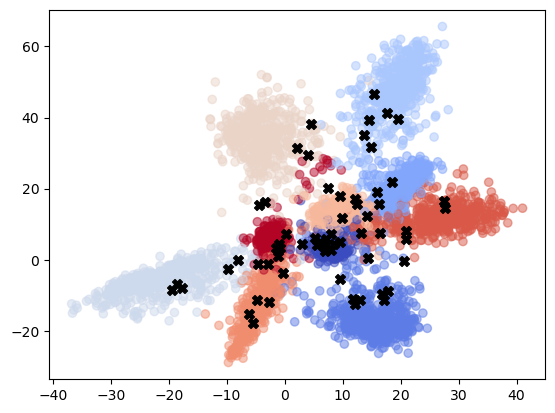

In [20]:
num_samples = 5000
encoded_samples = encoder.predict(X_train[:num_samples])
# Visualize the points in the feature space
plt.scatter(encoded_samples[:, 0], encoded_samples[:, 1], alpha=0.5, c=y_train[:num_samples], cmap=plt.cm.coolwarm)

prototypes = keras.ops.convert_to_numpy(kdm_mnist.kdm.c_x)
# plot the prototypes
plt.scatter(prototypes[:, 0], prototypes[:, 1], c='k', marker='X', s=50)
plt.show()

The figure above show training samples mapped to the latent space with different colors according to the class. The prototypes are shown as black crosses. Note that the prototypes do not cover all the areas of the different classes in the latent space, rather they are positioned to maximize the classification performance.

In [21]:
# Evaluate the classifier
score = kdm_mnist.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])
score = kdm_mnist.evaluate(X_train, y_train, verbose=0)
print('Train loss:', score[0])
print('Train accuracy:', score[1])
print(f'Sigma: {kdm_mnist.kernel.sigma.numpy()}')

Test loss: 0.2364598512649536
Test accuracy: 0.9469000101089478
Train loss: 0.16437864303588867
Train accuracy: 0.9603333473205566
Sigma: 4.1837029457092285


Now, we will train a generative model, based on the same encoder. The generative model is trained to maximize the likelihood of the input data, as well as minimize the classification loss. The goal is to obtain more representative prototypes, since the prototypes learned using the discriminative model are not representative of the data distribution, since them are optimized to maximize the classification accuracy.

In [26]:
n_comp = 128

kdm_mnist_gen = KDMClassModel(encoded_size=encoded_size,
                            dim_y=dim_y,
                            encoder=encoder,
                            n_comp=n_comp,
                            sigma=kdm_mnist.kernel.sigma.numpy(),
                            generative=1.0 # this value indicates a generative model
                            )

# initialize the prototypes using random samples from the training set
idx = np.random.randint(X_train.shape[0], size=n_comp)
kdm_mnist_gen.init_components(X_train[idx], keras.ops.one_hot(y_train[idx], 10), 
                          init_sigma=False)

print(f'Sigma: {kdm_mnist_gen.kernel.sigma.numpy()}')

# Compile the model
kdm_mnist_gen.compile(optimizer=optimizers.Adam(learning_rate=1e-3),
                    loss=losses.sparse_categorical_crossentropy,
                    metrics=[metrics.sparse_categorical_accuracy])

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Sigma: 4.1837029457092285


In [27]:
# Train the kdm discriminative model
kdm_mnist_gen.fit(X_train, y_train, validation_data=(X_val[:1000], y_val[:1000]), epochs=10, batch_size=128, verbose=1)
print(f'Final Sigma: {kdm_mnist_gen.kernel.sigma.numpy()}')


Epoch 1/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 17s 179ms/step - loss: 11.9247 - sparse_categorical_accuracy: 0.9466 - val_loss: 12.0767 - val_sparse_categorical_accuracy: 0.9270
Epoch 2/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 17s 178ms/step - loss: 11.9020 - sparse_categorical_accuracy: 0.9487 - val_loss: 12.0715 - val_sparse_categorical_accuracy: 0.9280
Epoch 3/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 17s 179ms/step - loss: 11.8985 - sparse_categorical_accuracy: 0.9434 - val_loss: 12.0543 - val_sparse_categorical_accuracy: 0.9300
Epoch 4/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 17s 179ms/step - loss: 11.8567 - sparse_categorical_accuracy: 0.9500 - val_loss: 12.0530 - val_sparse_categorical_accuracy: 0.9290
Epoch 5/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 17s 178ms/step - loss: 11.8659 - sparse_categorical_accuracy: 0.9462 - val_loss: 12.0401 - val_sparse_categorical_accuracy: 0.9300
Epoch 6/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 17s 179ms/step - loss: 11.8686 - sparse_categorical_accuracy: 0.9504 - val_loss: 12.0335 - val_sparse_categorical_acc

157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step


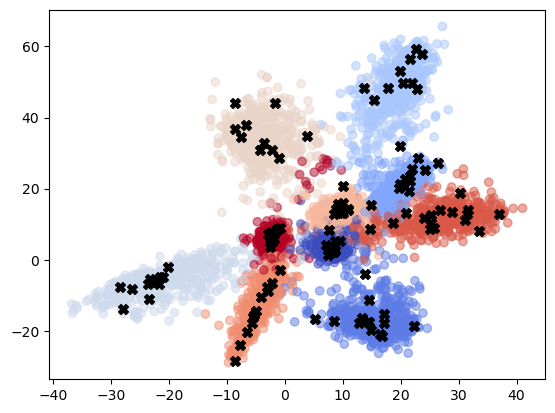

In [28]:
num_samples = 5000
encoded_samples = encoder.predict(X_train[:num_samples])
# Visualize the points in the feature space
plt.scatter(encoded_samples[:, 0], encoded_samples[:, 1], alpha=0.5, c=y_train[:num_samples], cmap=plt.cm.coolwarm)

prototypes = keras.ops.convert_to_numpy(kdm_mnist_gen.kdm.c_x)
# plot the prototypes
plt.scatter(prototypes[:, 0], prototypes[:, 1], c='k', marker='X', s=50)
plt.show()

In [29]:
# Evaluate the classifier
score = kdm_mnist_gen.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])
score = kdm_mnist_gen.evaluate(X_train, y_train, verbose=0)
print('Train loss:', score[0])
print('Train accuracy:', score[1])
print(f'Sigma: {kdm_mnist_gen.kernel.sigma.numpy()}')

Test loss: 11.941686630249023
Test accuracy: 0.9373000264167786
Train loss: 11.821456909179688
Train accuracy: 0.950166642665863
Sigma: 4.005020618438721


## Generator model

We can build a generator taking advantage of the symmetry of the KDM layer. Basically we change the role of the x-prototypes and the y-prototypes. The entry to the model will be a 10D vector that represents probability distribution of the digits to generate . The output of the KDM layer will be a probability distribution on the latent space. We can sample from this distribution to generate new samples that we will decode to obtain the generated digit. First we will train a decoder.

In [ ]:

def create_decoder(base_depth, encoded_size):
    decoder = keras.Sequential([
        kl.InputLayer(shape=[encoded_size]),
        kl.Reshape([1, 1, encoded_size]),
        kl.Conv2DTranspose(2 * base_depth, 6, strides=1,
                            padding='valid', activation=keras.ops.leaky_relu),
        kl.Conv2DTranspose(2 * base_depth, 5, strides=1,
                            padding='same', activation=keras.ops.leaky_relu),
        kl.Conv2DTranspose(2 * base_depth, 5, dilation_rate=2,
                            padding='valid', activation=keras.ops.leaky_relu),
        kl.Conv2DTranspose(base_depth, 5, strides=1,
                            padding='same', activation=keras.ops.leaky_relu),
        kl.Conv2DTranspose(base_depth, 5, dilation_rate=2,
                            padding='valid', activation=keras.ops.leaky_relu),
        kl.Conv2DTranspose(base_depth, 4, dilation_rate=2,
                            padding='valid', activation=keras.ops.leaky_relu),
        kl.Conv2D(filters=1, kernel_size=5, strides=1,
                    padding='same', activation=None),    
    ])
    return decoder

decoder = create_decoder(base_depth, encoded_size)
inputs = keras.layers.Input(shape=input_shape)
ae_model = keras.Sequential([inputs,
                            encoder,
                            decoder                            
                           ])
encoder.trainable = False

ae_model.compile(optimizer=optimizers.Adam(learning_rate=1e-4),
            loss=losses.BinaryCrossentropy(from_logits=True))

ae_model.fit(X_train, X_train, epochs=20, batch_size=128, verbose=1)

Epoch 1/2
94/94 ━━━━━━━━━━━━━━━━━━━━ 96s 1s/step - loss: 0.5646
Epoch 2/2
94/94 ━━━━━━━━━━━━━━━━━━━━ 94s 1s/step - loss: 0.2846


Let's plot some generated digits. The digits generated from the autoencoder are fuzzy because of the small dimension of the latent space. 

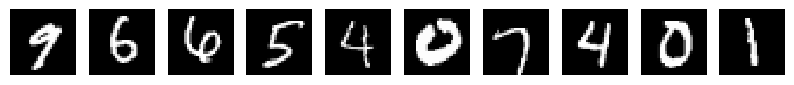

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


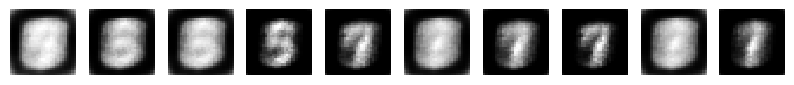

In [32]:
display_imgs(X_test[20:30])
prediction = ae_model.predict(X_test[20:30])

prediction = keras.ops.convert_to_numpy(
    keras.ops.sigmoid(prediction))
display_imgs(prediction)

Now we define the generator model. It receives a 10D vector that represents the probability distribution of the digits to generate. The output of the KDM layer is a probability distribution on the latent space. We can sample from this distribution to generate new samples that we will decode to obtain the generated digit. 

In [34]:
from keras import Model
from keras.layers import Input
from kdm.layers import CosineKernelLayer, KDMLayer

def create_generator_model(clf_model):
        inputs_gen = Input(shape=(10,))
        kernel_gen = CosineKernelLayer()
        kdm_gen = KDMLayer(kernel=kernel_gen, 
                                   dim_x=10, 
                                   dim_y=clf_model.encoded_size, 
                                   n_comp=clf_model.n_comp)
        kdm_gen.c_x.assign(clf_model.kdm.c_y)
        kdm_gen.c_y.assign(clf_model.kdm.c_x)
        kdm_gen.c_w.assign(clf_model.kdm.c_w)
        rho_y_gen = kdm.utils.pure2dm(inputs_gen)
        rho_x_gen = kdm_gen(rho_y_gen)
        gen_model = Model(inputs_gen, rho_x_gen)
        return gen_model

gen_model = create_generator_model(kdm_mnist_gen)
gen_model.compile()

In [35]:
import tensorflow as tf

import tensorflow_probability as tfp
tfd = tfp.distributions

def dm2distrib(dm, sigma):
    '''
    Creates a Gaussian mixture distribution from the components of a density
    matrix with an RBF kernel 
    Arguments:
     dm: tensor of shape (bs, n, d + 1)
     sigma: sigma parameter of the RBF kernel 
    Returns:
     gm: mixture of Gaussian distribution with shape (bs, )
    '''
    w, v = kdm.utils.dm2comp(dm)
    gm = tfd.MixtureSameFamily(reparameterize=True,
            mixture_distribution=tfd.Categorical(
                                    probs=w),
            components_distribution=tfd.Independent( tfd.Normal(
                    loc=v,  # component 2
                    scale=sigma / np.sqrt(2.)),
                    reinterpreted_batch_ndims=1))
    return gm

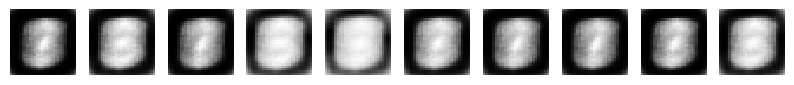

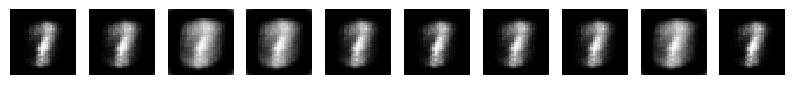

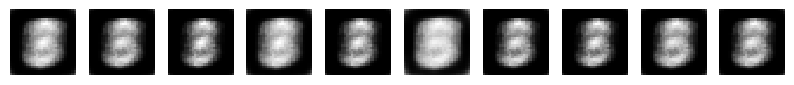

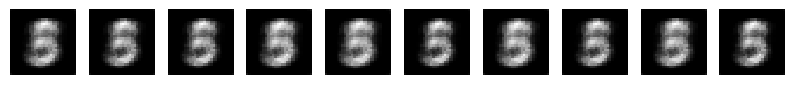

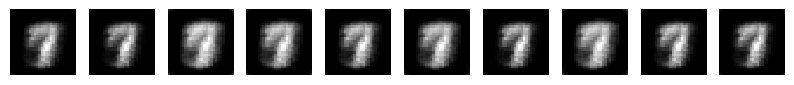

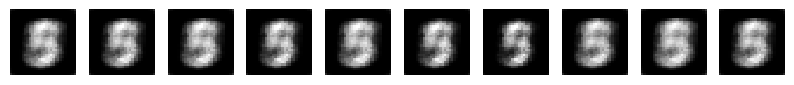

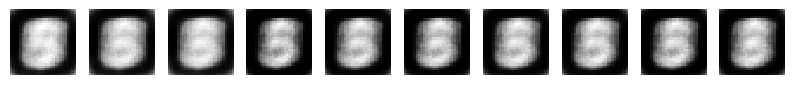

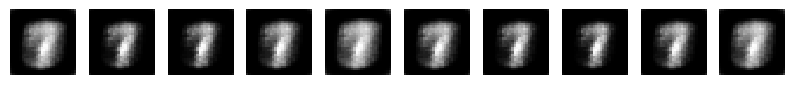

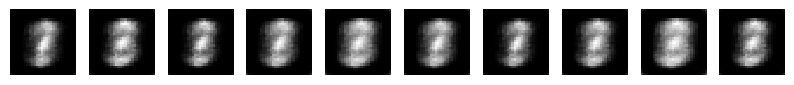

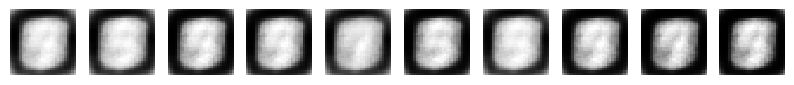

313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 45ms/step


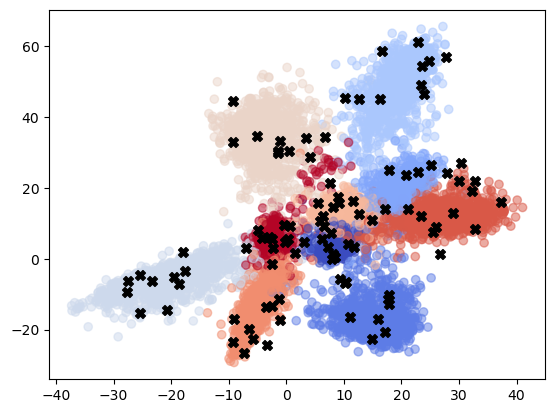

In [37]:
# Generate a set of distributions from the model for each digit
rho_y = keras.ops.convert_to_numpy(
    gen_model(keras.ops.eye(10)))
rho_y = np.float64(rho_y)

sigma = keras.ops.convert_to_numpy(kdm_mnist_gen.kernel.sigma)
sigma = np.float64(sigma)

distribs = dm2distrib(rho_y, sigma=sigma)
# Sample from the distributions
samples = []
for i in range(10):
    sample = distribs[i].sample(10).numpy()
    samples.append(sample)
    # Show the decoded images
    decoded_imgs = decoder(sample)
    decoded_imgs = keras.ops.convert_to_numpy(
        keras.ops.sigmoid(decoded_imgs))
    display_imgs(decoded_imgs)

# plot the samples in the feature space
num_train_samples = 10000
encoded_train = keras.ops.convert_to_numpy(encoder.predict(X_train[:num_train_samples]))

plt.scatter(encoded_train[:, 0], encoded_train[:, 1], alpha=0.5, 
            c=y_train[:num_train_samples], cmap=plt.cm.coolwarm)

# plot the prototypes
samples = np.concatenate(samples)
plt.scatter(samples[:, 0], samples[:, 1], c='k', marker='X', s=50)
plt.show()


Now we will generate digits from a label distribution that is a mixture of two digits. We will generate digits that are a mixture of 0 and 1. 

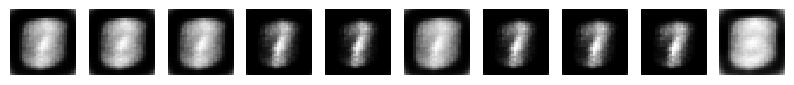

313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 44ms/step


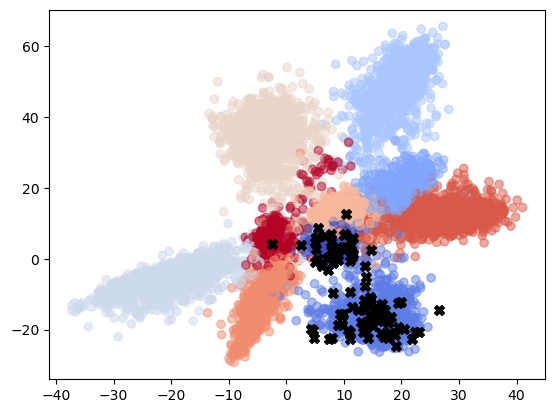

In [38]:
# Generate a set of distributions from the model for each digit
y_distrib = np.zeros((1,10))
y_distrib[0, 0] = 1 / np.sqrt(2)
y_distrib[0, 1] = 1 / np.sqrt(2)
rho_y = keras.ops.convert_to_numpy(
    gen_model(y_distrib))
rho_y = np.float64(rho_y)
x_distrib = dm2distrib(rho_y, sigma=sigma)[0]
# Sample from the distributions
sample = x_distrib.sample(100).numpy()
# Show the decoded images
decoded_imgs = decoder(sample[:10])
decoded_imgs = keras.ops.convert_to_numpy(
        keras.ops.sigmoid(decoded_imgs))
display_imgs(decoded_imgs)

# plot the samples in the feature space
num_train_samples = 10000
encoded_train = keras.ops.convert_to_numpy(encoder.predict(X_train[:num_train_samples]))

plt.scatter(encoded_train[:, 0], encoded_train[:, 1], alpha=0.5, 
            c=y_train[:num_train_samples], cmap=plt.cm.coolwarm)

# plot the prototypes
plt.scatter(sample[:, 0], sample[:, 1], c='k', marker='X', s=50)
plt.show()
